In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from fuzzywuzzy import fuzz
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

In [5]:
file_path = 'Pertanyaan Interview Indonesia.xlsx' 

df = pd.read_excel(file_path)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Question      145 non-null    object
 1   Answer        145 non-null    object
 2   Source        145 non-null    object
 3   Stage         145 non-null    object
 4   Sub_Category  145 non-null    object
 5   Intent        145 non-null    object
dtypes: object(6)
memory usage: 6.9+ KB


In [7]:
df.head()

,Question,Answer,Source,Stage,Sub_Category,Intent
0,Bisa ceritakan tentang diri kamu?,"Nama saya Aninda, seorang social media special...",https://glints.com/id/lowongan/pertanyaan-wawa...,Introductions,General,Open-Ended
1,Kenapa kamu apply untuk posisi ini?,Saya lebih menyukai lingkungan kerja yang cepa...,https://glints.com/id/lowongan/pertanyaan-wawa...,Broad,Motivational,Open-Ended
2,Dari mana kamu mendapatkan info pekerjaan ini?,Saya tahu lowongan pekerjaan ini dari teman sa...,https://glints.com/id/lowongan/pertanyaan-wawa...,Broad,Source,Closed-Ended
3,Apa kelebihan dan kekurangan kamu?,Kelebihan saya adalah saya mampu membagi waktu...,https://glints.com/id/lowongan/pertanyaan-wawa...,Broad,Strengths/Weaknesses,Open-Ended
4,Apa saja yang kamu tahu tentang posisi dan per...,Saya tahu bahwa posisi ini membutuhkan hard sk...,https://glints.com/id/lowongan/pertanyaan-wawa...,Broad,Company Knowledge,Open-Ended


In [9]:
exact_dup = df.duplicated(subset=['Question']).sum()
print(f"Jumlah pertanyaan yang 100% sama (exact duplicate): {exact_dup}")

if exact_dup > 0:
    print("\nContoh duplicate:")
    print(df[df.duplicated(subset=['Question'], keep=False)][['Question', 'Answer']].head(6))

Jumlah pertanyaan yang 100% sama (exact duplicate): 1

Contoh duplicate:
                    Question  \
15   Apa pekerjaan impianmu?   
112  Apa pekerjaan impianmu?   

                                                Answer  
15   Saya ingin sekali menjadi penulis buku, teruta...  
112  Saya selalu tertarik dengan bagaimana data bis...  


In [10]:
def find_fuzzy_duplicates(df, threshold=90):
    questions = df['Question'].astype(str).tolist()
    duplicates = []
    seen = set()
    for i in range(len(questions)):
        if i in seen: continue
        for j in range(i+1, len(questions)):
            score = fuzz.ratio(questions[i].lower(), questions[j].lower())
            if score > threshold:
                duplicates.append((i, j, questions[i], questions[j], score))
                seen.add(j)
    return duplicates

fuzzy_dups = find_fuzzy_duplicates(df, threshold=90)
print(f"Pertanyaan mirip (>90%): {len(fuzzy_dups)} pasang")

if len(fuzzy_dups) > 0:
    print("\nContoh 5 teratas:")
    for i, j, q1, q2, score in fuzzy_dups[:5]:
        print(f"\n{score}% mirip:")
        print(f"   → {q1}")
        print(f"   → {q2}")

Pertanyaan mirip (>90%): 5 pasang

Contoh 5 teratas:

100% mirip:
   → Apa pekerjaan impianmu?
   → Apa pekerjaan impianmu?

92% mirip:
   → Apa tipe lingkungan pekerjaan yang kamu sukai?
   → Apa jenis lingkungan pekerjaan yang kamu sukai?

92% mirip:
   → Mengapa kami harus mempekerjakan Anda?
   → Mengapa kami harus mempekerjakan kamu?

93% mirip:
   → Apa yang Anda ketahui tentang perusahaan kami?
   → Apa yang kamu ketahui tentang perusahaan kami?

94% mirip:
   → Apa yang paling disukai dari posisi terakhir kamu?
   → Apa yang paling tidak disukai dari posisi terakhir kamu?


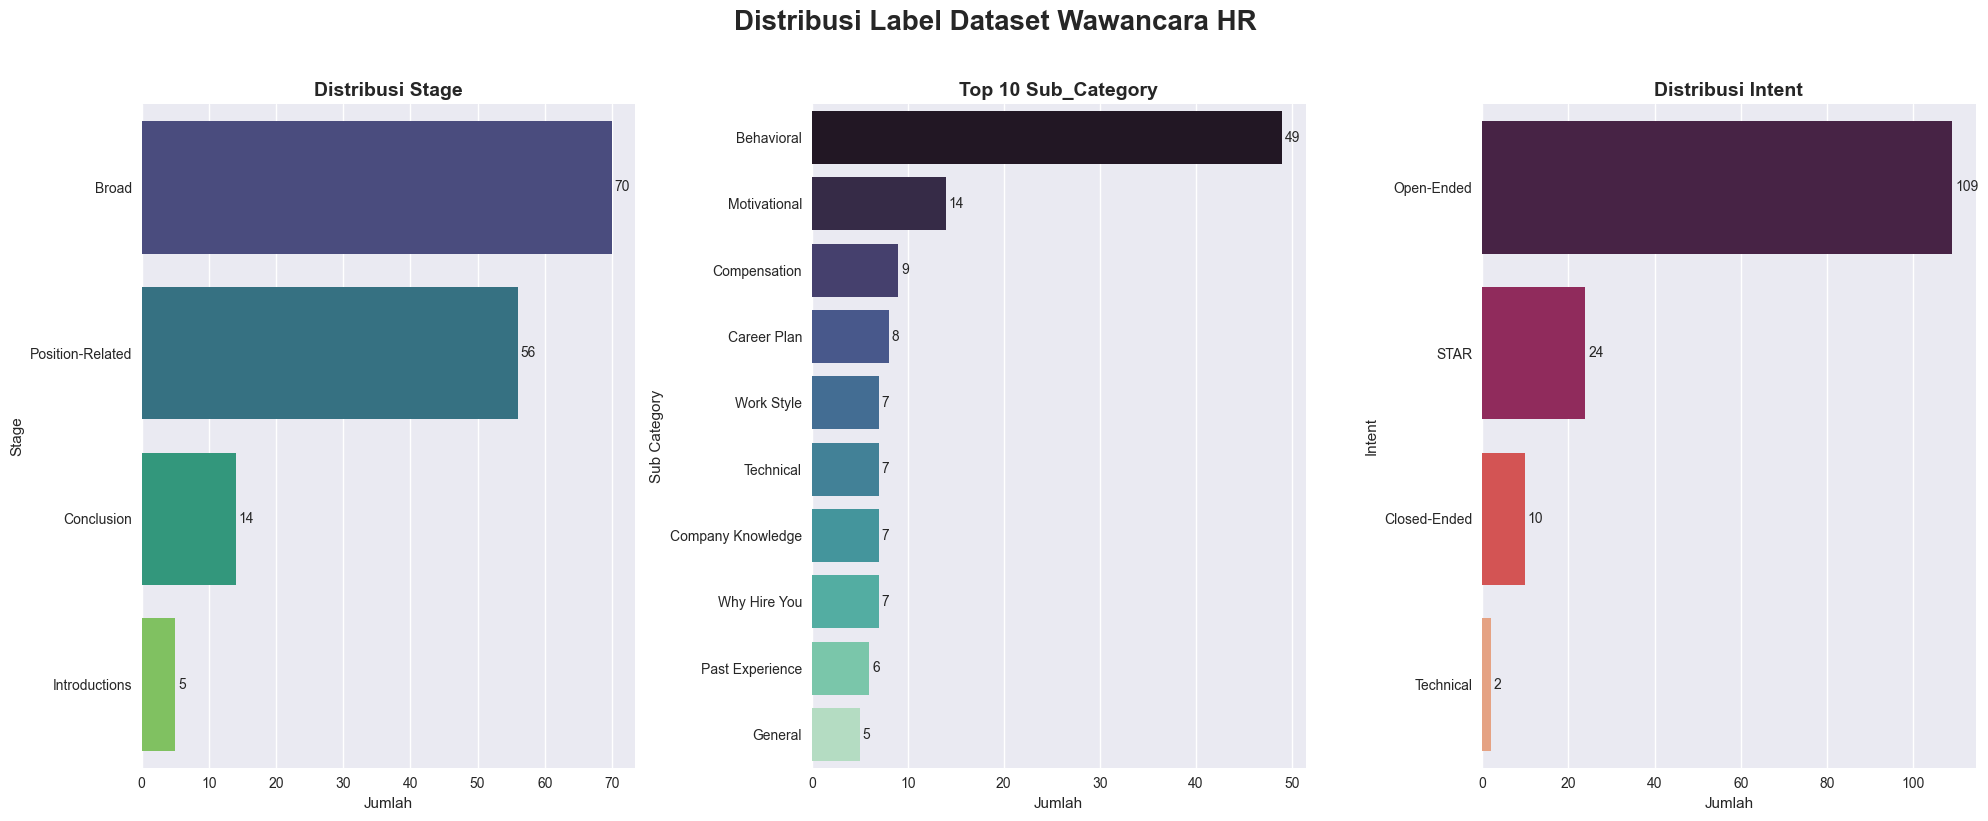

In [13]:
# Distribusi 3 Label Utama (Stage, Sub_Category, Intent)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Distribusi Label Dataset Wawancara HR', fontsize=20, fontweight='bold', y=1.02)

# 1. Stage
sns.countplot(data=df, y='Stage', order=df['Stage'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Stage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah')
axes[0].set_ylabel('Stage')

# 2. Sub_Category — Top 10
top_sub = df['Sub_Category'].value_counts().head(10)
sns.barplot(y=top_sub.index, x=top_sub.values, ax=axes[1], palette='mako')
axes[1].set_title('Top 10 Sub_Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah')
axes[1].set_ylabel('Sub Category')

# 3. Intent
sns.countplot(data=df, y='Intent', order=df['Intent'].value_counts().index, ax=axes[2], palette='rocket')
axes[2].set_title('Distribusi Intent', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Jumlah')
axes[2].set_ylabel('Intent')

# Beautify: tambah nilai di ujung bar
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=10)

plt.tight_layout()
plt.show()

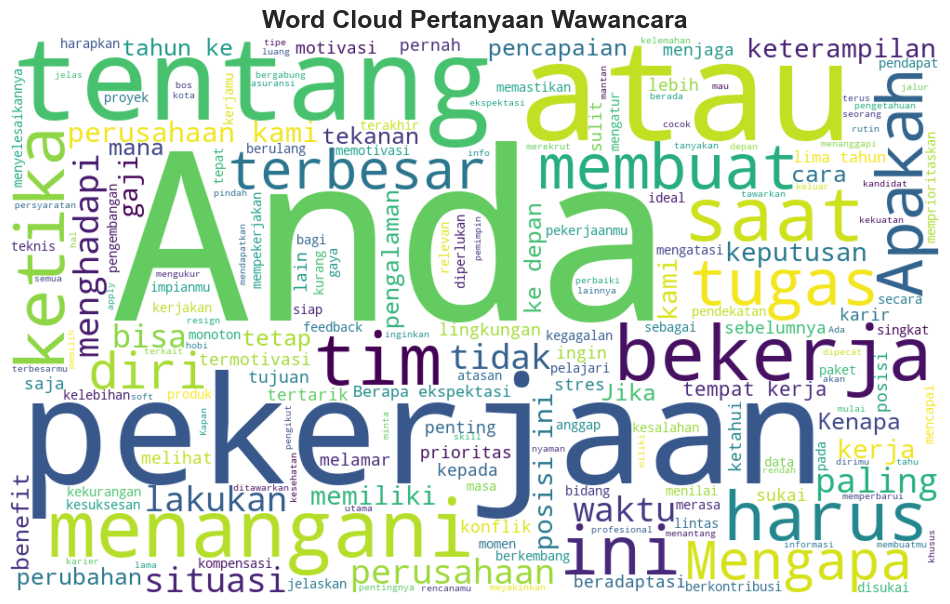

In [14]:
text = " ".join(df['Question'].astype(str))

wordcloud = WordCloud(
    width=1000, height=600,
    background_color='white',
    stopwords=['apa', 'kamu', 'bagaimana', 'ceritakan', 'yang', 'di', 'dan', 'dengan', 'untuk', 'dalam', 'dari']
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Pertanyaan Wawancara', fontsize=18, fontweight='bold')
plt.show()

In [15]:
print("RINGKASAN DATASET")
print("="*60)
print(f"Total baris               : {len(df)}")
print(f"Unique pertanyaan         : {df['Question'].nunique()}")
print(f"Exact duplicate           : {exact_dup}")
print(f"Fuzzy duplicate (>90%)    : {len(fuzzy_dups)}")
print(f"Stage terbanyak           : {df['Stage'].value_counts().idxmax()} ({df['Stage'].value_counts().max()})")
print(f"Intent terbanyak          : {df['Intent'].value_counts().idxmax()} ({df['Intent'].value_counts().max()})")
print(f"Sumber terbanyak          : {df['Source'].value_counts().idxmax()}")
print(f"Rata-rata panjang pertanyaan  : {df['Question'].astype(str).apply(len).mean():.1f} karakter")

RINGKASAN DATASET
Total baris               : 145
Unique pertanyaan         : 144
Exact duplicate           : 1
Fuzzy duplicate (>90%)    : 5
Stage terbanyak           : Broad (70)
Intent terbanyak          : Open-Ended (109)
Sumber terbanyak          : https://dealls.com/pengembangan-karir/pertanyaan-wawancara-kerja
Rata-rata panjang pertanyaan  : 54.8 karakter
